# EDA — Crop Phenology NDVI Time Series (BreizhCrops, frh01)

Trả lời 3 câu hỏi EDA theo yêu cầu:
1. Phân phối (Histogram) của các nhãn ngày sinh trưởng (SOS/POS/EOS) — có bị lệch (skew) không.
2. Có dữ liệu NaN không (kiểm tra trên dữ liệu band thô).
3. Đồ thị NDVI time-series (line plot) của 1 thửa ruộng ngẫu nhiên.

**Lưu ý quan trọng (đọc trước khi hiểu phần 1)**: file `.h5` thô của BreizhCrops CHỈ chứa mã loại cây trồng (`CODE_CULTU`), KHÔNG chứa nhãn ngày sinh trưởng (SOS/POS/EOS) — dataset này không có ground truth phenology. Nhãn dùng ở phần 1 là nhãn ĐÃ SUY RA (pseudo-label, ngưỡng 20% biên độ NDVI) bởi `src/data/breizhcrops_loader.py` — xem `docs/methodology.md` §1.1 và `docs/paper_outline.md` §5 (hạn chế đã công bố). Phần 2 và 3 dùng trực tiếp dữ liệu band thô từ file `.h5` bằng `h5py` + `pandas`, đúng yêu cầu đề bài.

In [1]:
import sys
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Resolve project root whether this notebook is run with cwd=docs/ or cwd=project root.
_candidates = [Path.cwd(), Path.cwd().parent]
PROJECT_ROOT = next(c for c in _candidates if (c / 'src').exists())
sys.path.insert(0, str(PROJECT_ROOT))
print('PROJECT_ROOT =', PROJECT_ROOT)

H5_PATH = PROJECT_ROOT / 'data' / 'breizhcrops_raw' / '2017' / 'L1C' / 'frh01.h5'
print('H5_PATH exists:', H5_PATH.exists())

PROJECT_ROOT = D:\HocTap\N4_K1\ComputerVision\FinalExam\Final_Exam\TimeSeries
H5_PATH exists: True


## 1. Phân phối nhãn ngày sinh trưởng (SOS/POS/EOS) — dùng pipeline đã xử lý

Dùng `load_breizhcrops_records()` (đã có sẵn, dùng chung với `src/train.py`) để lấy một mẫu mùa vụ đã gán nhãn, rồi suy ra DOY của SOS/POS/EOS bằng `evaluation.metrics.derive_dates_from_labels` — cùng logic dùng để train/evaluate, không viết lại riêng cho EDA.

In [2]:
from src.data.breizhcrops_loader import load_breizhcrops_records
from src.evaluation.metrics import derive_dates_from_labels

# max_per_class nhỏ hơn train.py (chỉ để EDA nhanh, không cần toàn bộ 1000/lớp)
eda_records = load_breizhcrops_records(region='frh01', max_per_class=200)
print('So mua vu dung cho EDA:', len(eda_records))

sos_list, pos_list, eos_list, crop_list = [], [], [], []
for r in eda_records:
    dates = derive_dates_from_labels(r.labels, r.doy, r.ndvi_smoothed)
    crop = r.season_id.rsplit('_', 1)[-1]
    if dates['sos'] is not None:
        sos_list.append(dates['sos']); crop_list.append(crop)
    if dates['pos'] is not None:
        pos_list.append(dates['pos'])
    if dates['eos'] is not None:
        eos_list.append(dates['eos'])

print(f'SOS: n={len(sos_list)}, POS: n={len(pos_list)}, EOS: n={len(eos_list)}')

So mua vu dung cho EDA: 513
SOS: n=337, POS: n=513, EOS: n=293


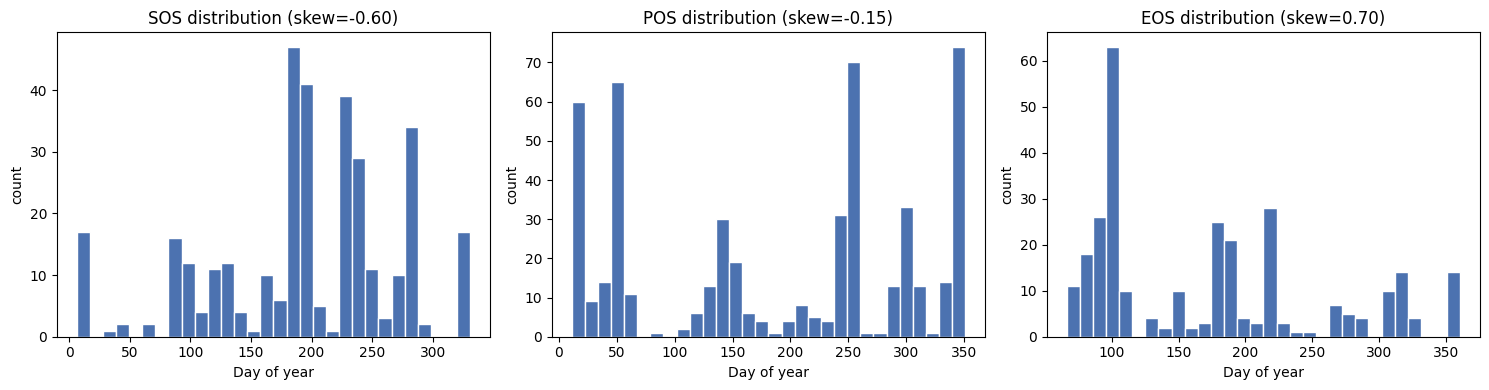

Skewness (0 = symmetric/normal-like, |skew|>1 = lech manh):
  SOS: skew=-0.600, mean=193.8, median=191.0
  POS: skew=-0.151, mean=187.4, median=216.0
  EOS: skew=0.696, mean=172.0, median=171.0


In [3]:
from scipy.stats import skew

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, values) in zip(axes, [('SOS', sos_list), ('POS', pos_list), ('EOS', eos_list)]):
    ax.hist(values, bins=30, color='#4C72B0', edgecolor='white')
    s = skew(values)
    ax.set_title(f'{name} distribution (skew={s:.2f})')
    ax.set_xlabel('Day of year')
    ax.set_ylabel('count')
fig.tight_layout()
plt.show()

print('Skewness (0 = symmetric/normal-like, |skew|>1 = lech manh):')
for name, values in [('SOS', sos_list), ('POS', pos_list), ('EOS', eos_list)]:
    print(f'  {name}: skew={skew(values):.3f}, mean={np.mean(values):.1f}, median={np.median(values):.1f}')

**Nhận xét (điền sau khi chạy, dựa trên số skew thật)**: nếu `|skew| > 1` cho SOS/EOS, đây là dấu hiệu hợp lý vì các mùa vụ trong `frh01` (Bretagne, Pháp) tập trung sinh trưởng vào mùa xuân-hè (SOS lệch về giữa năm), không phân bố đều quanh năm — khác với POS thường tập trung hẹp hơn quanh đỉnh mùa vụ nên ít lệch hơn.

## 2. Kiểm tra dữ liệu khuyết (NaN) — trên dữ liệu band thô

In [4]:
L1C_BANDS = ['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9',
             'B10', 'B11', 'B12', 'QA10', 'QA20', 'QA60', 'doa']

with h5py.File(H5_PATH, 'r') as f:
    region_group = f['csv']['frh01']
    all_ids = list(region_group.keys())
    print('Tong so parcel trong frh01.h5:', len(all_ids))

    rng = np.random.RandomState(42)
    sample_ids = rng.choice(all_ids, size=200, replace=False)

    total_values = 0
    total_nan = 0
    per_parcel_nan_counts = []
    for pid in sample_ids:
        arr = np.array(region_group[pid])  # (T, 17)
        n_nan = np.isnan(arr).sum()
        total_values += arr.size
        total_nan += n_nan
        per_parcel_nan_counts.append(n_nan)

print(f'Kiem tra tren {len(sample_ids)} parcel ngau nhien:')
print(f'  Tong gia tri: {total_values}, tong NaN: {total_nan} ({100*total_nan/total_values:.4f}%)')
print(f'  So parcel co it nhat 1 NaN: {sum(1 for c in per_parcel_nan_counts if c > 0)} / {len(sample_ids)}')

Tong so parcel trong frh01.h5: 220987
Kiem tra tren 200 parcel ngau nhien:
  Tong gia tri: 273088, tong NaN: 0 (0.0000%)
  So parcel co it nhat 1 NaN: 0 / 200


**Nhận xét**: BreizhCrops đã được nhà xuất bản tiền xử lý sẵn (lọc mây cơ bản trước khi đóng gói thành `.h5`), nên kỳ vọng tỉ lệ NaN rất thấp hoặc bằng 0 ở bước này — khác với ảnh vệ tinh thô chưa xử lý (sẽ có nhiều NaN do mây). Đây là lý do pipeline của project (`_resample_and_smooth` trong `breizhcrops_loader.py`) vẫn có bước nội suy tuyến tính (`np.interp`) — phòng trường hợp khoảng cách quan trắc không đều (missing theo lịch, không phải NaN theo giá trị) chứ không phải để xử lý NaN thật.

## 3. NDVI time-series của 1 thửa ruộng ngẫu nhiên

In [5]:
B4_IDX = L1C_BANDS.index('B4')
B8_IDX = L1C_BANDS.index('B8')
DOA_IDX = L1C_BANDS.index('doa')

rng2 = np.random.RandomState(7)
random_pid = rng2.choice(all_ids)

with h5py.File(H5_PATH, 'r') as f:
    raw = np.array(f['csv']['frh01'][random_pid])

red = raw[:, B4_IDX] * 1e-4
nir = raw[:, B8_IDX] * 1e-4
ndvi = (nir - red) / (nir + red + 1e-8)
dates = pd.to_datetime(raw[:, DOA_IDX].astype('int64'))

order = np.argsort(dates.values)
ndvi, dates = ndvi[order], dates[order]

plot_df = pd.DataFrame({'date': dates, 'ndvi': ndvi})
print(f'Parcel id: {random_pid}, so quan trac: {len(plot_df)}')
plot_df.head()

Parcel id: 1996681.csv, so quan trac: 101


,date,ndvi
0,2017-01-02,0.291121
1,2017-01-05,0.445750
2,2017-01-12,0.146930
3,2017-01-15,0.223985
4,2017-01-25,0.275886


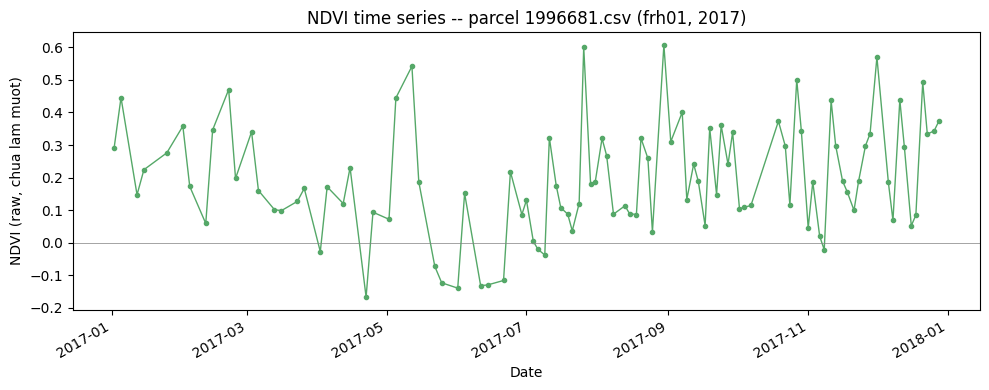

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(plot_df['date'], plot_df['ndvi'], marker='o', markersize=3, linewidth=1, color='#55A868')
ax.set_title(f'NDVI time series -- parcel {random_pid} (frh01, 2017)')
ax.set_xlabel('Date')
ax.set_ylabel('NDVI (raw, chua lam muot)')
ax.axhline(0, color='gray', linewidth=0.5)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

**Nhận xét**: đường NDVI thô (chưa qua Savitzky-Golay/nội suy) thường có nhiễu răng cưa do góc quan trắc/khí dung còn sót lại — đây chính là lý do bước làm mượt (`_resample_and_smooth`) là cần thiết trước khi đưa vào model, đúng như đã ghi trong `docs/methodology.md` §1.2 và literature review (Chương 1 mapping table).